In [1]:
import sys
sys.path.append("..")

from datetime import datetime
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, sample_forward_process, interpolate_parameters
from physical_diffusion_fns.learning_fns import solve_quadratic_score_matching_cg_only, setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, plot_sampels_energy_marginals_for_SGM_vs_ES
from physical_diffusion_fns.network_fns import setup_overdamped_SDE, solve_SDE, setup_energy_fn, setup_duffing_network_analytical_derivatives, setup_score_matching_loss_hessian

jax.config.update("jax_enable_x64", True) 

# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a mixture of 2 Gaussians in 2d - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal of target distributions

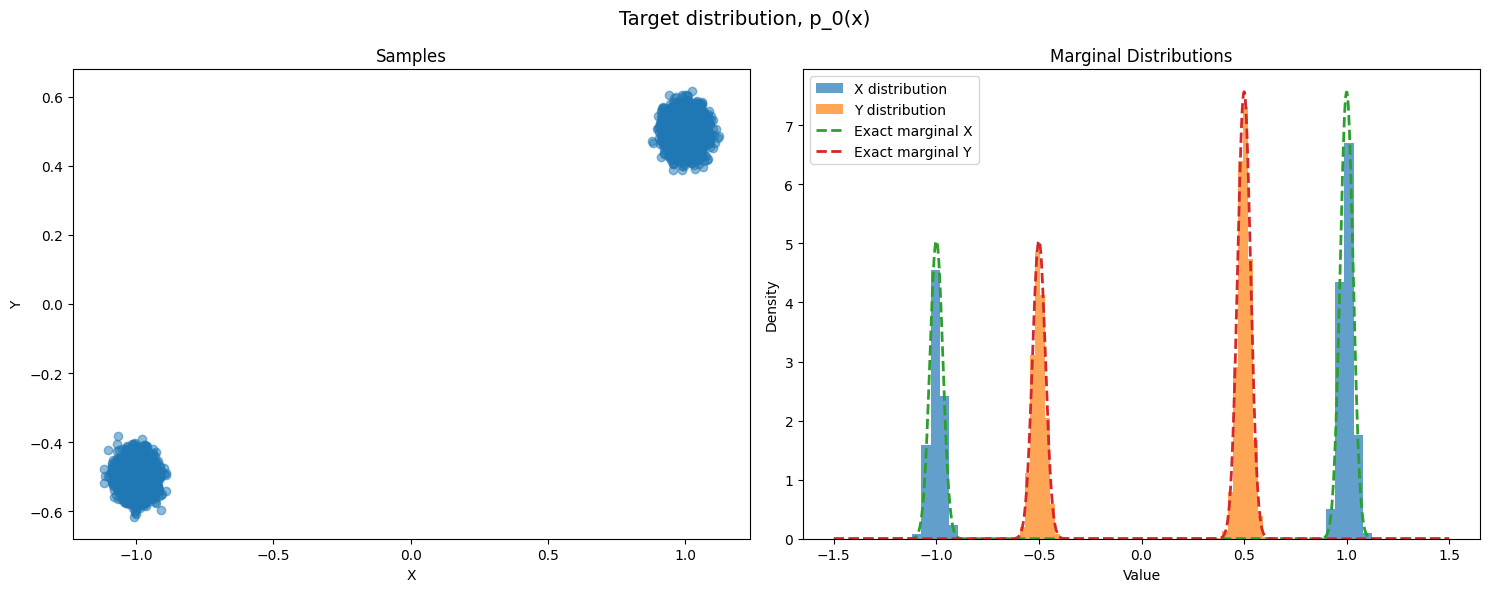

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size, topology and temperature

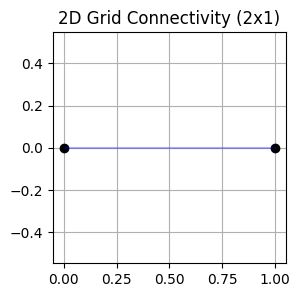

In [5]:
Temp = 0.1
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy
Up to 6th order local energies and up to 4th order coupling energies

In [6]:
k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
k_6_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
c_duff_0 = jnp.zeros(num_connections)
biases_0 = jnp.zeros(N_osc)
params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
constraint_indices = constraint_indices_k6_self

# Set up energy fn
energy_fn = setup_energy_fn(connectivity, unflatten)
# Set up analytical derivatives
gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
hessian_fn = setup_score_matching_loss_hessian(gradient_wrt_params_fn)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


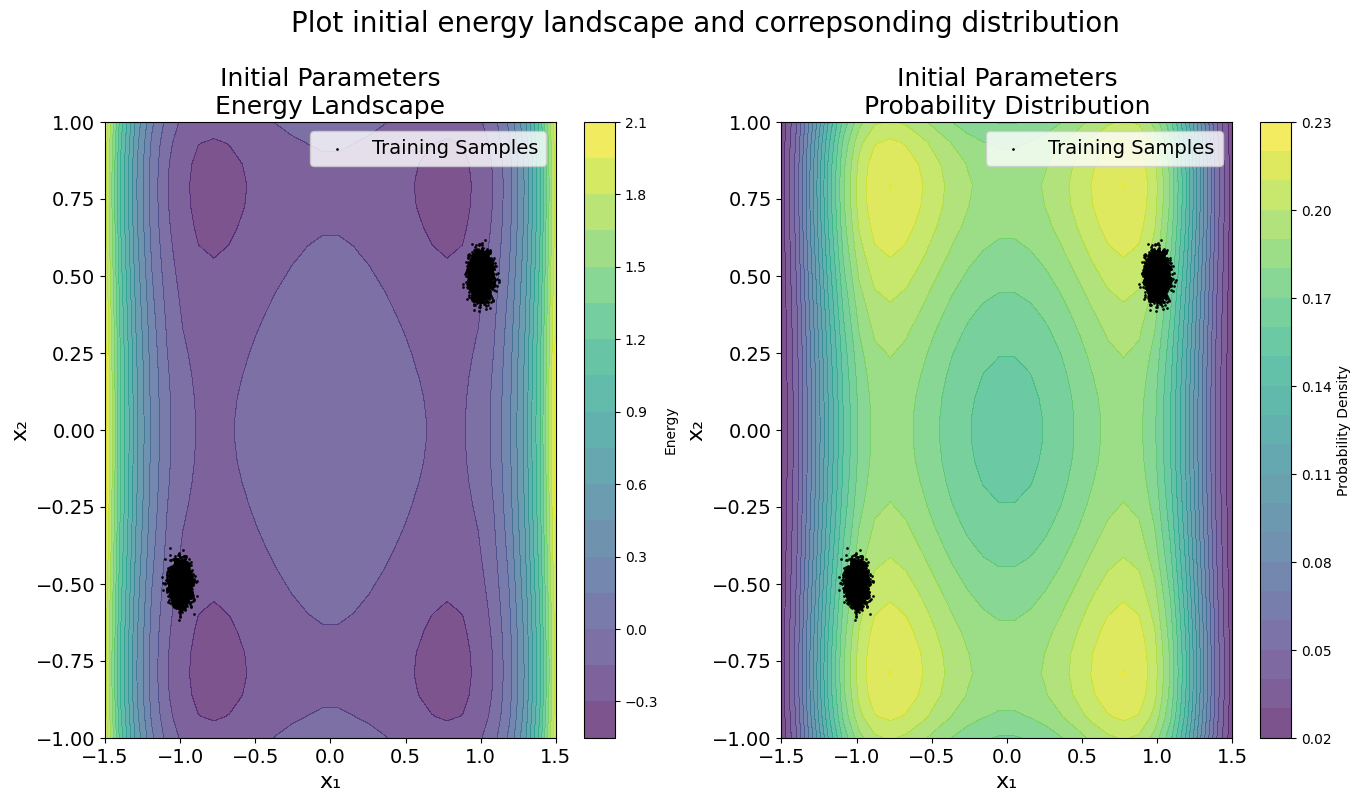

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1.5, 1.5),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape and correpsonding distribution" 
)

# Learning

In [8]:
# Use analytical version for much better performance
loss_fn_per_batch, gradient_fn_per_batch = setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical(
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
    k_b=1.0, T=Temp
)
maximize = False
learning_rate = Temp

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 5
t_forward = 5.
forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)

# Optimization parameters (full dataset, no batching)
n_epochs = 100000
window_size=50
tolerance=1e-1
patience=10

In [10]:
problem_type_folder = f"mixture_of_2_gaussians_in_2d_using_Hessian_CG"
physics_folder = f"Network_with_6th_order_local_and_duffing_coupling_energy"
temperature_folder = f"Temp_{Temp}"
optimization_folder = (
        f"t_forward_{t_forward}_"
        f"n_timesteps_{n_time_steps}_"
        f"full_n_{n_samples}_"
        f"window_{window_size}_"
        f"tol_{tolerance}_"
        f"patience_{patience}")

# Setup output directories
current_date = datetime.now().strftime("%Y_%m_%d")

base_dir = "../out"
output_dir = os.path.join(base_dir, current_date,problem_type_folder,physics_folder,temperature_folder, optimization_folder)
final_plots_folder = os.path.join(output_dir, 'final_plots')
optimization_plots_folder = os.path.join(output_dir, 'optimization_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(final_plots_folder, exist_ok=True)
os.makedirs(optimization_plots_folder, exist_ok=True)
print(f"Final plots directory: {final_plots_folder}")
print(f"Optimization plots directory: {optimization_plots_folder}")

save_fig = True

Final plots directory: ../out/2026_02_23/mixture_of_2_gaussians_in_2d_using_Hessian_CG/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.1/t_forward_5.0_n_timesteps_5_full_n_10000_window_50_tol_0.1_patience_10/final_plots
Optimization plots directory: ../out/2026_02_23/mixture_of_2_gaussians_in_2d_using_Hessian_CG/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.1/t_forward_5.0_n_timesteps_5_full_n_10000_window_50_tol_0.1_patience_10/optimization_plots


t_idx: 0, t_curr: 0.0


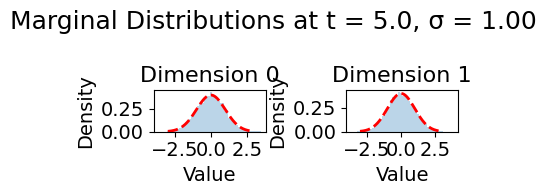

Hessian condition number: 12184524.851730015
Best loss: -5.4794e+01
Found at epoch: 1


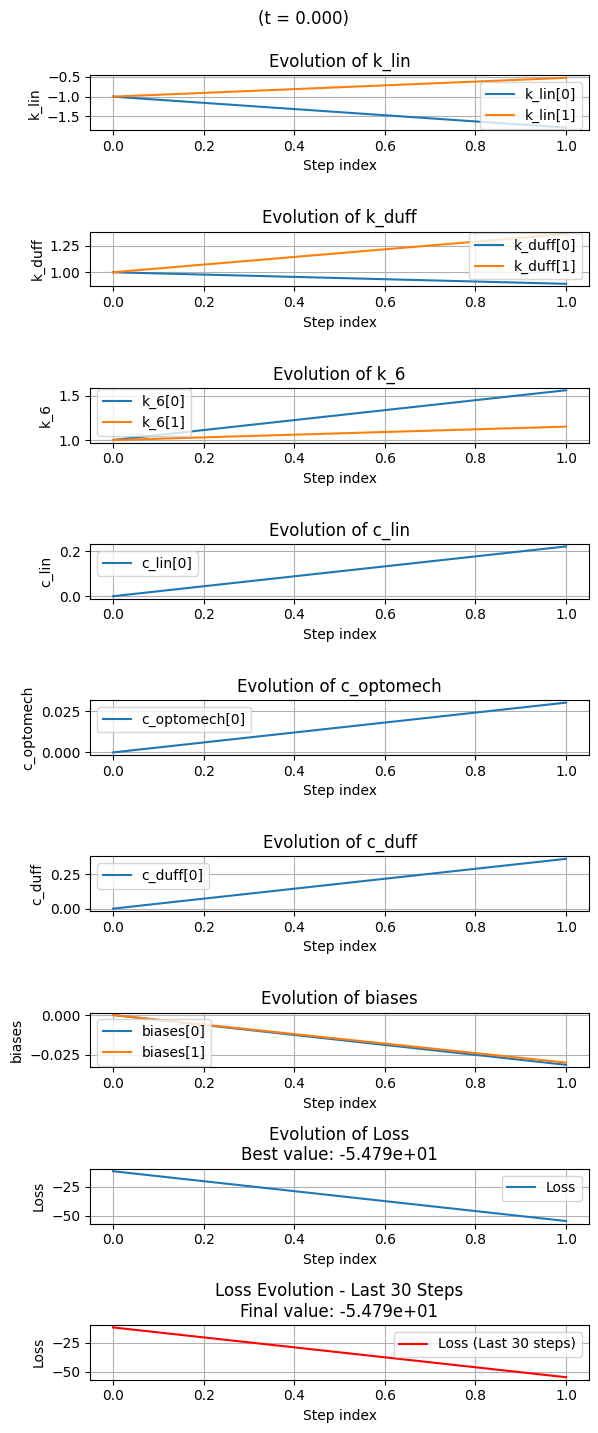

t_idx: 1, t_curr: 1.25
Hessian condition number: 2913.3690942447006
Best loss: -3.7375e+00
Found at epoch: 1


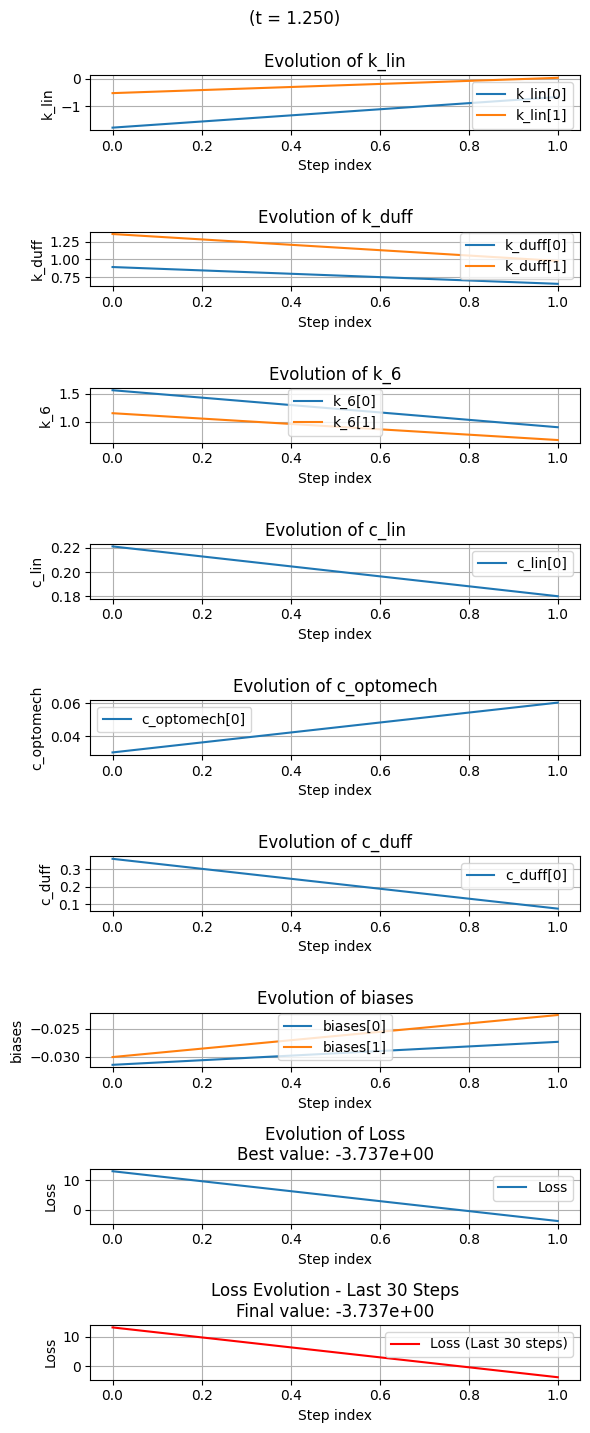

t_idx: 2, t_curr: 2.5
Hessian condition number: 2750.240078486198
Best loss: -7.4547e+00
Found at epoch: 1


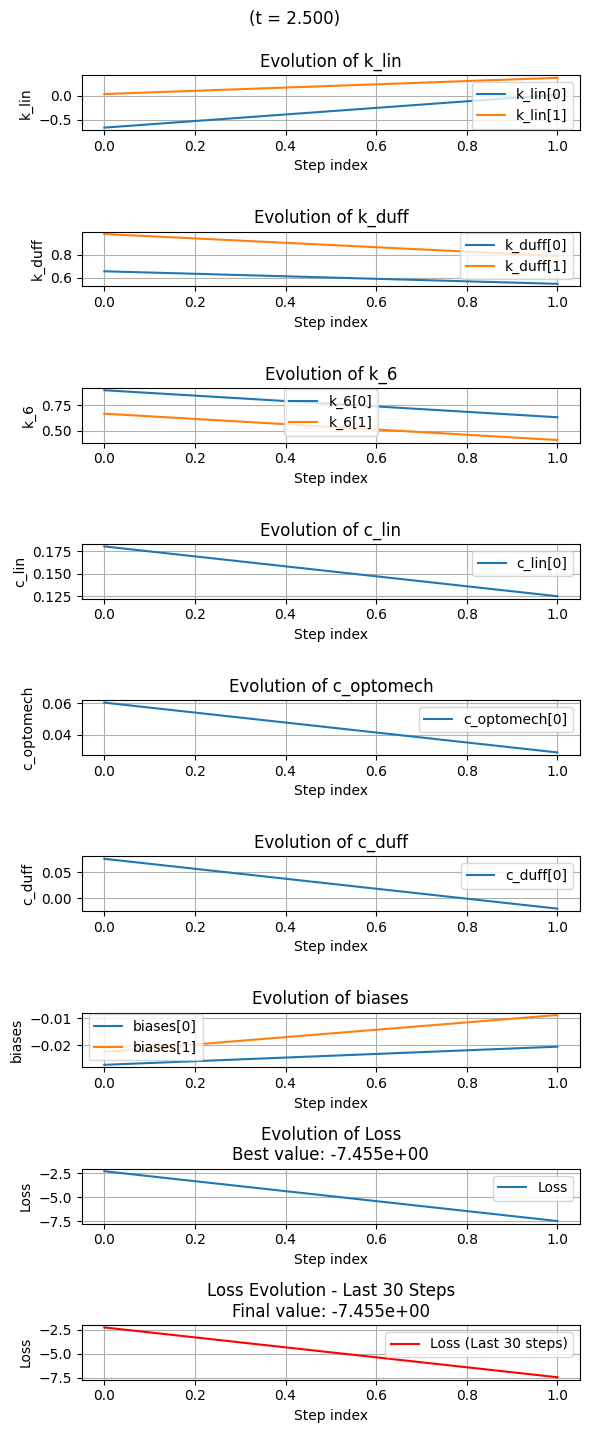

t_idx: 3, t_curr: 3.75
Hessian condition number: 4677.1031352697355
Best loss: -8.9721e+00
Found at epoch: 1


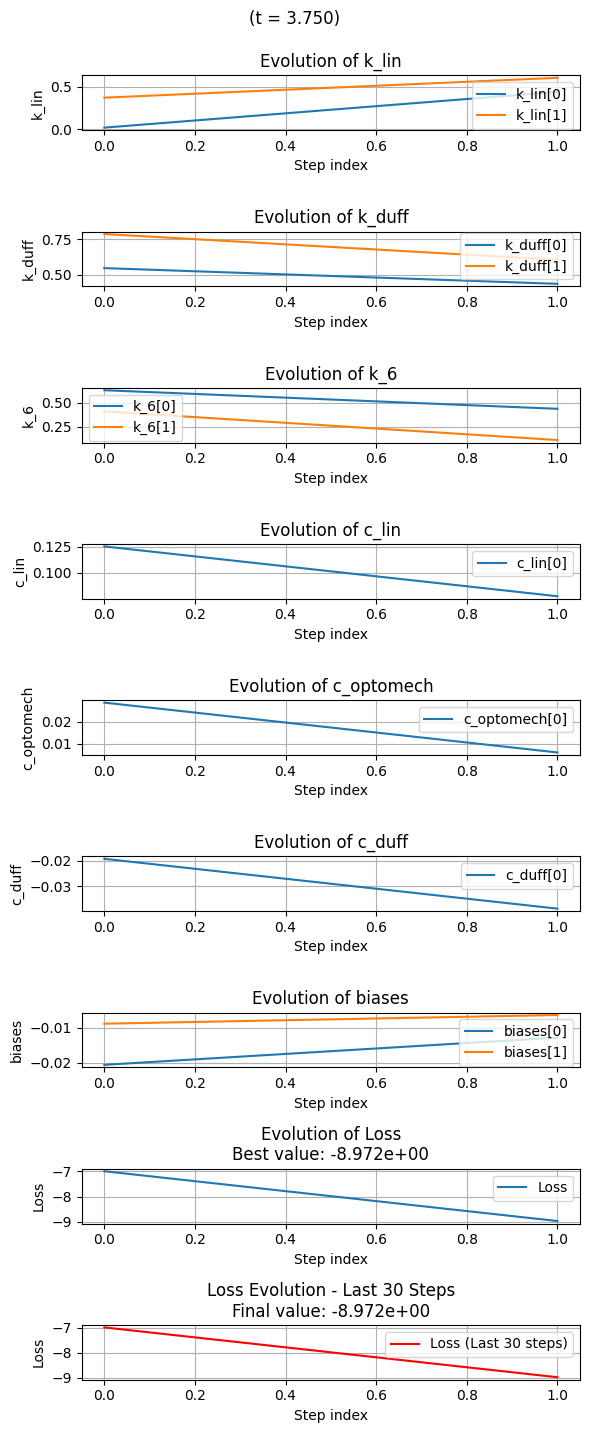

t_idx: 4, t_curr: 5.0
Hessian condition number: 3425.6294786774456
Best loss: -9.8644e+00
Found at epoch: 1


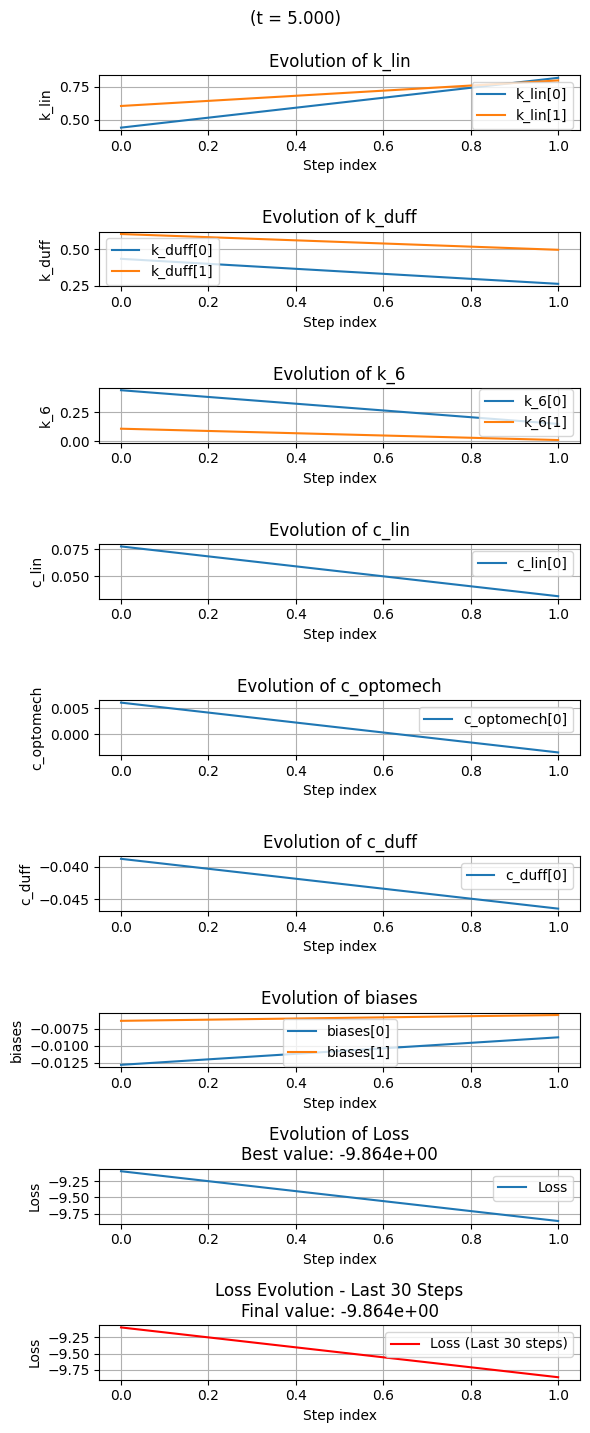

Optimization complete; saved parameters to ../out/2026_02_23/mixture_of_2_gaussians_in_2d_using_Hessian_CG/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.1/t_forward_5.0_n_timesteps_5_full_n_10000_window_50_tol_0.1_patience_10


In [11]:
# Setup optimization parameters
mask = jnp.ones(params_flattened_initial.shape[0])

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 1     # Plot every nth step

params_history_all_t = []
current_params = params_flattened_initial

params_history_path = f"{output_dir}/params_history.npy"
# if os.path.exists(params_history_path):
#     # Load existing parameters
#     print('Loading existing parameters from', params_history_path)
#     params_history_all_t = jnp.load(params_history_path)
# else:
# print('No existing parameters found, running the optimization') 
# Loop over time points
for t_idx, t_curr in enumerate(forward_time_pts):
    print(f"t_idx: {t_idx}, t_curr: {t_curr}")
    optimization_key, optimization_subkey = jr.split(optimization_key)
    
    if t_idx == 0:
        samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=1., samples0=samples_target, key=optimization_key)
        plot_forward_marginals(samples_0, t_forward, 1., beta=1.0, path=final_plots_folder, save_fig=save_fig, fontsize=16, plot_show=True)
    
    # Full dataset, no batching
    sampler = lambda key: sample_forward_process(
            t_curr, n_samples=n_samples, D=Temp, sigma_final=1., samples0=samples_target, key=key, beta=1
        )
    
    samples = sampler(optimization_subkey)
    H = hessian_fn(samples, current_params)
    cond = jnp.linalg.cond(H)  # condition number
    print(f"Hessian condition number: {cond}")
        
    # CG-only: one Newton step via CG, saves params/loss at each CG iteration
    # hessian_reg, max_delta_ratio, use_pinv_fallback prevent param explosion; set use_pinv_fallback=False to see CG evolution
    params_history, loss_history, current_params, best_loss, best_epoch = solve_quadratic_score_matching_cg_only(
        params_initial=current_params,
        sampler=sampler,
        hessian_fn=hessian_fn,
        gradient_fn_per_batch=gradient_fn_per_batch,
        loss_fn_per_batch=loss_fn_per_batch,
        mask=mask,
        key=optimization_subkey,
        maximize=maximize,
        constraint_indices=constraint_indices,
        hessian_reg=1e-2,
        step_scale=1.0,
        cg_tol=1e-8,
        cg_max_iter=100,
        max_delta_ratio=0.5,
        use_pinv_fallback=True,
        pinv_rcond=1e-4,
    )   
    
    params_history_all_t.append(current_params)
    
    if plot_steps:
        if t_idx % plot_slice == 0:
            # Plot optimization progress
            plot_parameter_evolution(
                params_history=params_history,
                loss_history=loss_history,
                best_params=current_params,
                best_loss=best_loss,
                best_idx=best_epoch,
                time = t_curr,
                time_index = t_idx,
                unflatten=unflatten,
                N_osc=N_osc,
                title=f"(t = {t_curr:.3f})",
                maximize=maximize,
                labels_on=True,
                save_fig=save_fig,
                path=optimization_plots_folder,
                param_names=params_names,
                plot_show=True
            )
        
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)
jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

print('Optimization complete; saved parameters to', output_dir)

### Interpolate and plot parameter evolution

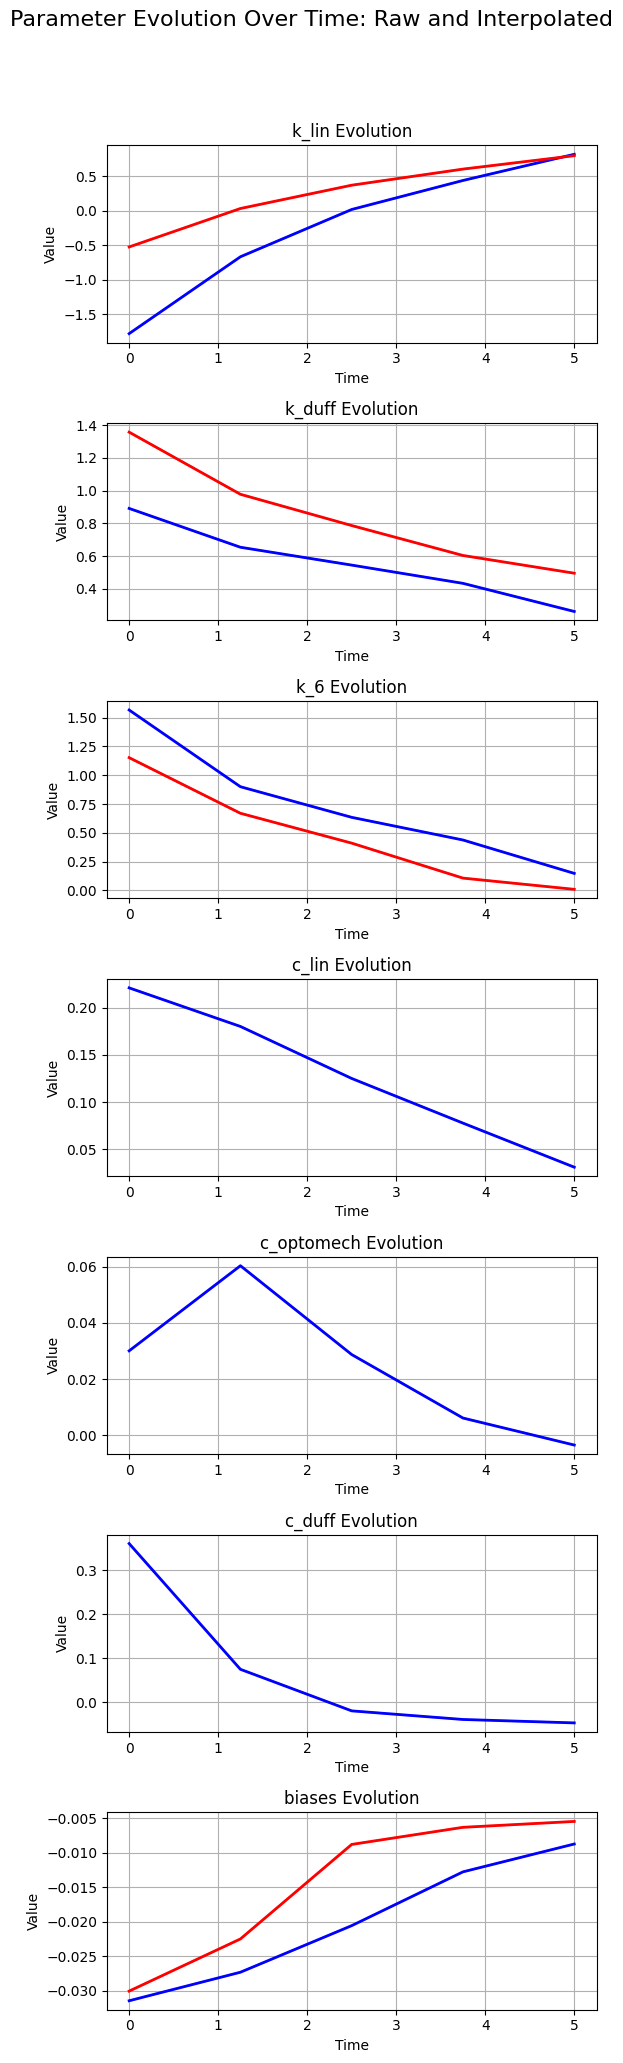

In [12]:
# Get interpolator functions
params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc, save_fig=True, path=final_plots_folder, log_scale=False,plot_show=True)


### Run reverse SDE:

In [ ]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)

params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-2
rtol = 1e-3

n_trajectories = 2000

final_states_path = f"{output_dir}/SGM_samples_num_trajectories_{n_trajectories}_atol_{atol}_rtol_{rtol}.npy"

# if os.path.exists(final_states_path):
#     print(f"Loading existing final states from {final_states_path}")
#     final_states = jnp.load(final_states_path)
# else:
print("No cached final states found, solving SDE...")
# Generate multiple initial states from the asymptotic Gaussian N(0, Temp * I)
reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
initial_states = jnp.sqrt(Temp) * jr.normal(subkey_initial, shape=(n_trajectories, N))

# Generate a key for each initial condition
keys_brownian = jr.split(reverse_sde_key, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

jnp.save(final_states_path, final_states)
print(f"Saved final states to {final_states_path}")

No cached final states found, solving SDE...


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

### Run equillibirum SDE

In [ ]:
fraction_of_trajectories_to_run = 0.00001
t1 = n_trajectories*t_forward*fraction_of_trajectories_to_run
sde_samples_direct_path = f"{output_dir}/equilibrium_sampling_fraction_{fraction_of_trajectories_to_run}.npy"
if os.path.exists(sde_samples_direct_path):
    # Load existing parameters
    print('Loading existing equilibrium trajectory', sde_samples_direct_path)
    sde_samples_direct = jnp.load(sde_samples_direct_path)
else:
    print('No existing equilibrium trajectory found, running optimization')   
    drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(0), N_osc, Temp=Temp, time_dependent_parms=False)
    t0 = 0.0
    ts = jnp.linspace(t0, t1, n_trajectories)
    dt0 = ts[1] - ts[0]
    initial_state = jnp.array([-.0,0.])

    reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
    solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0,atol=atol,rtol=rtol)
    sde_samples_direct = solution_direct.ys
    jnp.save(sde_samples_direct_path, sde_samples_direct)


## Plot samples

In [ ]:
plot_sampels_energy_marginals_for_SGM_vs_ES(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,
    n_points=50,
    num_bins=75,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
    colormap='bwr',
    contour_linewidth=2.5,
    scatter_size=4,
    scatter_alpha=0.9,
    plot_folder=final_plots_folder,
    n_trajectories=n_trajectories,
    atol=atol,
    rtol=rtol,
    Temp=Temp
)
